In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv", encoding="ISO-8859-1")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (9800, 18)

Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
print("Descriptive statistics for Sales:")
print(df['Sales'].describe())

print("\nMode of Sales:", df['Sales'].mode()[0])

Descriptive statistics for Sales:
count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

Mode of Sales: 12.96


When I looked at the summary statistics for Sales, I noticed the average order 
value is around $230, but the median is only about  $54. That's a big gap, and 
it tells me the data is skewed — most orders are small, but a few very large 
ones (the max order is over $22,000) are pulling the average up. The standard 
deviation is even bigger than the mean, which confirms just how much order 
sizes vary across the dataset.

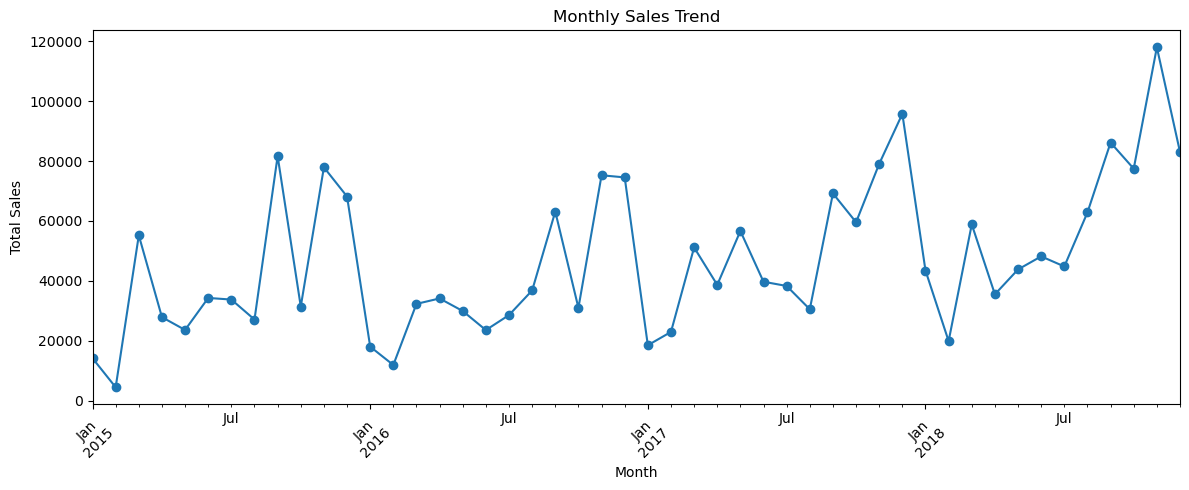

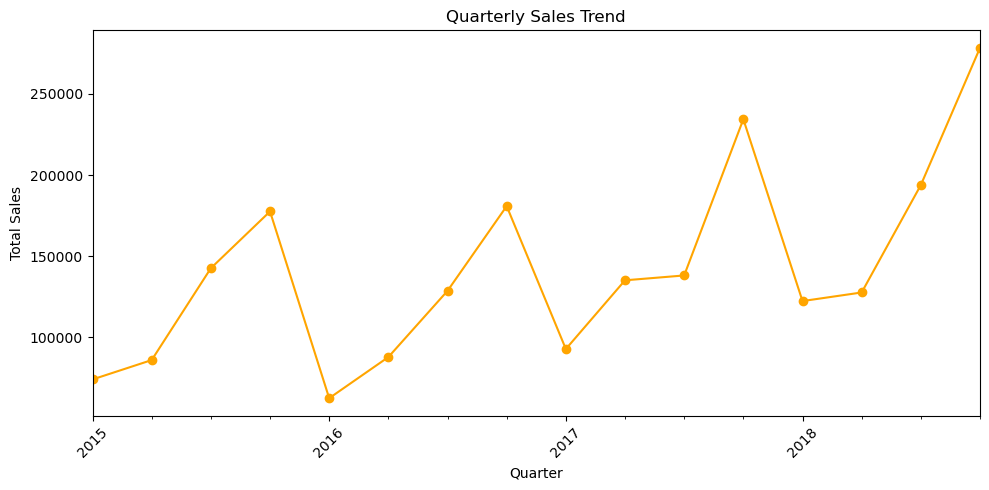

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
quarterly_sales = df.groupby(df['Order Date'].dt.to_period('Q'))['Sales'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='line', marker='o', color='orange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Looking at the monthly trend, sales are pretty volatile month to month, but 
there's a clear pattern: almost every year, sales spike hard toward the end 
of the year (around November/December), then drop back down in January before 
climbing again. The quarterly view makes this even clearer — Q4 is consistently 
the strongest quarter every single year, and the very last quarter in the 
dataset is the highest point overall. This looks like a strong holiday/year-end 
shopping effect, and sales also seem to be trending upward year over year overall.

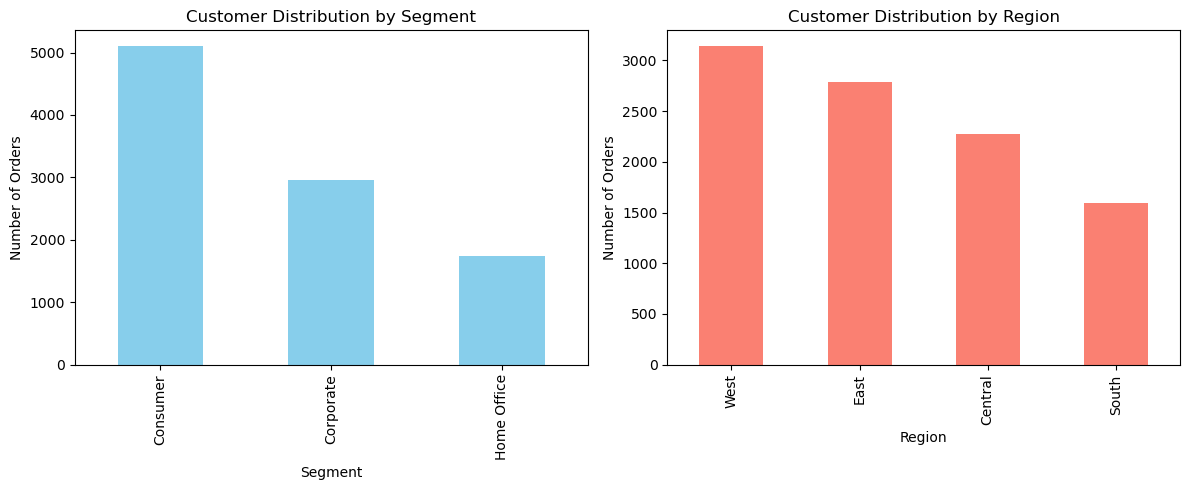

In [4]:
segment_counts = df['Segment'].value_counts()
region_counts = df['Region'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

segment_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Customer Distribution by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Orders')

region_counts.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Customer Distribution by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

Since this dataset doesn't have age or gender fields, I used Segment and Region 
as a substitute to look at customer distribution instead. The Consumer segment 
clearly makes up the largest share of orders — more than Corporate and Home 
Office combined. On the regional side, the West region has the most orders, 
followed by East, Central, and South. This tells me the business's order volume 
is driven mainly by everyday consumers rather than corporate clients, and the 
West region is the strongest market.

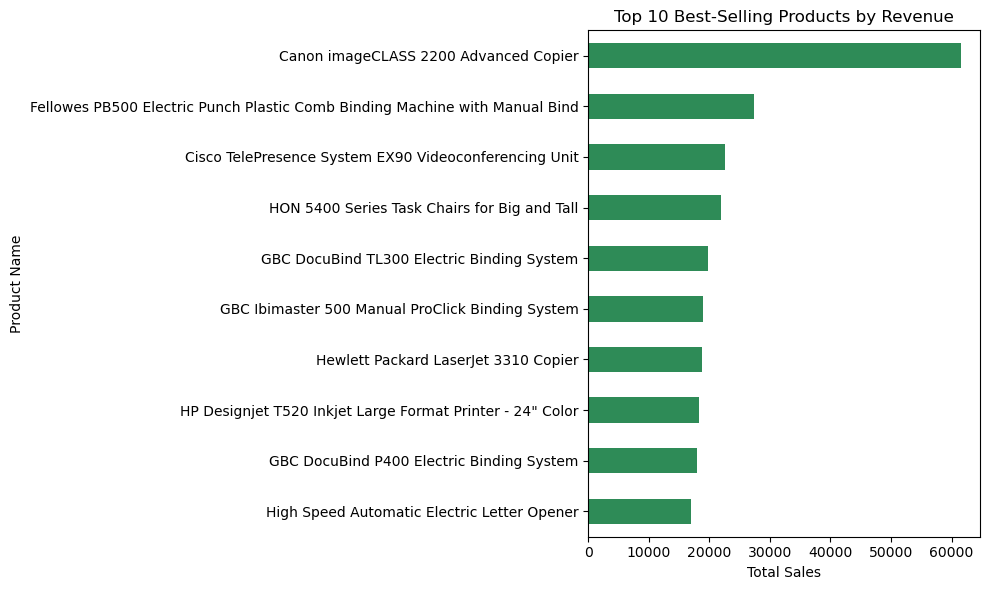

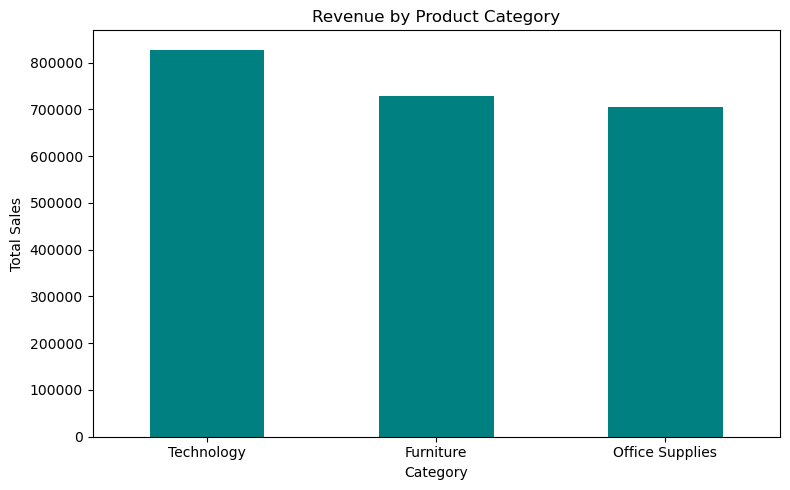

In [5]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='seagreen')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar', color='teal')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The Canon imageCLASS 2200 Advanced Copier is by far the top-selling product — 
its revenue is more than double the next closest product, which really stands 
out. Most of the other top 10 products are higher-priced equipment like 
binding machines, task chairs, and printers, rather than small everyday items. 
At the category level, Technology brings in the most revenue, followed closely 
by Furniture and Office Supplies, which are fairly close to each other. This 
tells me high-ticket individual products are doing a lot of the heavy lifting 
in the Technology category specifically.

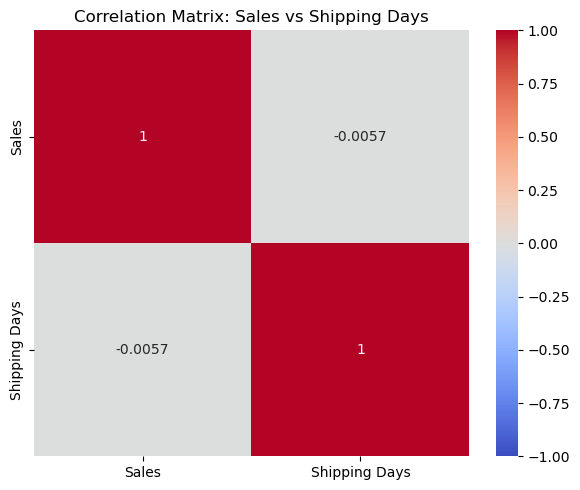

In [6]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

numeric_cols = df[['Sales', 'Shipping Days']]
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix: Sales vs Shipping Days')
plt.tight_layout()
plt.show()

I created a Shipping Days feature (the gap between order date and ship date) 
so I'd have a second numeric variable to compare against Sales. The correlation 
between them turned out to be -0.0057, which is essentially zero. This tells 
me shipping speed has no real relationship with order value — customers 
placing large orders aren't shipped noticeably faster or slower than customers 
placing small orders. It's a useful finding in the sense that it rules out a 
factor I might have assumed mattered.

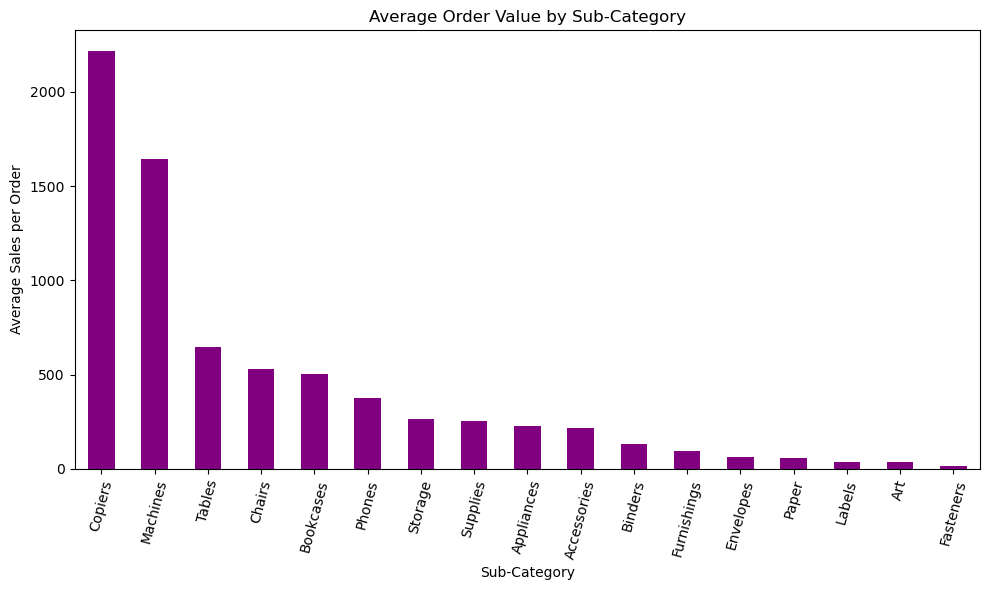

In [7]:
avg_order_by_subcat = df.groupby('Sub-Category')['Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_order_by_subcat.plot(kind='bar', color='purple')
plt.title('Average Order Value by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Average Sales per Order')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Observation: Average Order Value by Sub-Category
This one surprised me a bit. Copiers have by far the highest average order 
value (over $2,200), with Machines a distant second wclose to $1,650. Both of 
these are technology-adjacent items, which lines up with Technology leading 
overall category revenue earlier — but what's interesting is that the rest of 
the list drops off sharply. Everyday office items like Paper, Labels, Art, and 
Fasteners have very low average order values, even though they're probably 
ordered frequently. This tells me the business's revenue is really concentrated 
in a small number of expensive equipment sales rather than spread evenly 
across product types.

## Conclusion & Business Recommendations

Looking back at everything I found in this analysis, here are three specific 
recommendations I'd make:

1. **Prepare inventory and staffing for Q4 demand spikes.** Sales consistently 
   peak in the last quarter every year, likely due to holiday shopping. The 
   business should scale up stock and support ahead of this period rather than 
   reacting to it.

2. **Double down on high-value equipment sales, but diversify around them.** 
   A huge share of revenue comes from a small number of expensive products 
   like the Canon copier and other machines/copiers. Relying this heavily on 
   a few products is risky — the business should both protect this segment 
   (with better warranties/support to justify premium pricing) and invest in 
   growing mid-tier product lines so revenue isn't so concentrated.

3. **Focus marketing on the Consumer segment and West region**, since they 
   already drive the most order volume — but also investigate why Corporate 
   and Home Office segments lag behind, since they may represent untapped 
   growth potential rather than a lost cause.